# Task 1, Financial AI: LLM-Powered Equity Research Assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dinojan9901/CDAZZDEV-MLE-DINOJAN/blob/main/task1_financial/notebook.ipynb)

Fetches real market data, computes five technical indicators from first principles with
no TA-Lib, retrieves news, and uses an LLM to produce validated sentiment and a reasoned
Buy, Hold or Sell call.

**Sections**

| | Covers | Marks |
|---|---|---|
| 1A | OHLCV, indicators, news, summary dictionary, robustness | 60 |
| 1B | Per-headline sentiment, signal reasoning, schema validation, prompt design | 40 |
| Bonus | Rendered research brief with an embedded chart | 5 |

## Setup

Runs unchanged locally or on Colab.

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not Path("CDAZZDEV-MLE-DINOJAN").exists():
        subprocess.run(["git", "clone", "-q", "https://github.com/Dinojan9901/CDAZZDEV-MLE-DINOJAN.git"], check=True)
    os.chdir("CDAZZDEV-MLE-DINOJAN")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
                   check=False)
    # Keys come from Colab Secrets, never from a cell. A committed token is a
    # listed disqualifier in the assessment brief.
    from google.colab import userdata
    for name in ("GROQ_API_KEY", "OPENROUTER_API_KEY"):
        try:
            value = userdata.get(name)
            if value:
                os.environ[name] = value
        except Exception:
            pass
else:
    root = Path.cwd()
    while root != root.parent and not (root / "common").is_dir():
        root = root.parent
    os.chdir(root)
    sys.path.insert(0, str(root))

from common import config
print("working dir :", Path.cwd().name)
print("providers   :", config.available_providers())
print("model       :", config.GROQ_MODEL)
print("fast model  :", config.GROQ_MODEL_FAST)

working dir : CDAZZDEV-MLE-DINOJAN
providers   : ['groq', 'openrouter']
model       : openai/gpt-oss-120b
fast model  : openai/gpt-oss-20b


# Task 1A, Data Pipeline

## Fetching OHLCV

Dates are derived from today, never hardcoded. A warm-up buffer of 260 trading days is
fetched *before* the two-year analysis window, because SMA200 needs 200 prior bars and
without the buffer the first year of the window would have no long average at all.

`auto_adjust=True` is load-bearing rather than cosmetic: NVDA split 10:1 in June 2024 and
an unadjusted series would corrupt every moving average across the split.

In [2]:
import logging
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")

from task1_financial.src import data, indicators as ind, news, summary as summary_mod

TICKER = "NVDA"

history = data.fetch_ohlcv(TICKER, years=2)
print(f"bars fetched        : {len(history.frame)}")
print(f"bars in 2y window   : {len(history)}")
print(f"date range          : {history.frame.index[0].date()} to {history.frame.index[-1].date()}")
print(f"analysis starts     : {history.analysis_start.date()}")
history.frame.tail()

bars fetched        : 751
bars in 2y window   : 501
date range          : 2023-09-05 to 2026-09-01
analysis starts     : 2024-09-02


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-08-26,212.639999,213.600006,209.229996,209.660004,179900000
2026-08-27,222.860001,230.470001,220.899994,227.979996,298909800
2026-08-28,227.360001,229.259995,216.809998,217.550003,195116400
2026-08-31,218.869995,221.300003,216.210007,220.779999,124702700
2026-09-01,216.610001,220.410004,215.100006,217.440002,99321017


## Indicators, computed from first principles

No TA-Lib. Two implementation choices worth stating:

**RSI uses true Wilder smoothing**, seeded with the simple mean of the first 14 gains,
not an `ewm` approximation. An EWM seeded on its first value drifts from published RSI
figures over the first few dozen bars.

**Bollinger bands use population standard deviation** (`ddof=0`) to match charting
convention. Pandas defaults to the sample deviation, which inflates the bands slightly.

In [3]:
enriched = ind.add_all(history.frame)
window = enriched.loc[enriched.index >= history.analysis_start]

cols = ["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
        "bb_upper", "bb_mid", "bb_lower", "bb_pct_b"]
print("null count inside the analysis window, all five indicators:")
print(window[cols].isna().sum().to_string())
window[cols].tail()

null count inside the analysis window, all five indicators:
Close          0
sma_50         0
sma_200        0
rsi_14         0
macd           0
macd_signal    0
macd_hist      0
bb_upper       0
bb_mid         0
bb_lower       0
bb_pct_b       0


,Close,sma_50,sma_200,rsi_14,macd,macd_signal,macd_hist,bb_upper,bb_mid,bb_lower,bb_pct_b
Date,,,,,,,,,,,
2026-08-26,209.660004,207.750599,195.370999,46.298393,1.545969,3.078984,-1.533015,231.689305,215.560501,199.431697,0.317082
2026-08-27,227.979996,208.161999,195.571348,61.321569,2.479907,2.959169,-0.479262,231.204586,217.207501,203.210416,0.884812
2026-08-28,217.550003,208.419999,195.665115,52.343541,2.351342,2.837604,-0.486262,229.835189,218.047501,206.259814,0.478898
2026-08-31,220.779999,208.621799,195.804445,54.562186,2.481482,2.766379,-0.284898,229.357203,218.754501,208.151800,0.595518
2026-09-01,217.440002,208.797599,195.923880,51.872910,2.288725,2.670848,-0.382123,229.186907,219.029501,208.872096,0.421757


### Verifying the indicators against a published source

Correctness is asserted against **Wilder's own worked example**, not against another
library. Nineteen reference RSI values are checked to within 0.02, which proves the
implementation independently of any TA package.

In [4]:
from task1_financial.tests import test_indicators
test_indicators.main()

  PASS  test_rsi_matches_wilder                (19 assertions)


  PASS  test_rsi_bounds_and_extremes           (3 assertions)
  PASS  test_sma                               (3 assertions)
  PASS  test_macd_against_manual_ema           (3 assertions)


  PASS  test_bollinger_population_std          (4 assertions)


  PASS  test_handles_gaps_and_short_series     (3 assertions)

6 tests passed, 35 assertions.


## News retrieval

Three sources are tried in order (yfinance, Yahoo RSS, Google News RSS), then deduplicated
and ranked.

Ranking is deliberately **binary**, on-topic versus off-topic, rather than by how many
times the company is named. Aggregator headlines pad in "(NASDAQ:NVDA)" and scored higher
than genuine editorial ones, which collapsed three sources back down to one.

In [5]:
headlines = news.fetch_news(TICKER, n=10, company_name="NVIDIA Corporation")

from collections import Counter
print(f"retrieved {len(headlines)} headlines")
print("source mix:", dict(Counter(h["source"] for h in headlines)))
print(f"on-topic  : {sum(1 for h in headlines if h['relevance'] > 0)} of {len(headlines)}")
print()
for i, h in enumerate(headlines, 1):
    print(f"{i:2d}. [{h['source']:10s}] {h['headline'][:78]}")

retrieved 10 headlines
source mix: {'yfinance': 4, 'yahoo_rss': 2, 'google_rss': 4}
on-topic  : 10 of 10

 1. [yfinance  ] Two deals, one Nvidia strategy: What's behind the chip giant's recent partners
 2. [yfinance  ] Hut 8 stock is a winner in a new deal between Anthropic and Nvidia-backed Lamb
 3. [yfinance  ] 5-Star Analyst Drops Massive Nvidia Stock Price Target
 4. [yfinance  ] A $3.5 Billion Reason Why Nvidia Stock in Focus
 5. [yahoo_rss ] Micron Stock Is Down 23% From Its Highs. Did Nvidia's CFO Just Give It the Gre
 6. [yahoo_rss ] SpaceX Picks Nvidia Chips for Orbital AI. What It Means for NVDA Stock
 7. [google_rss] Nvidia Just Gave a $267 Billion Warning That Micron Stock Could Crash Before 2
 8. [google_rss] Nvidia: Stock Price To Catch Up To Earnings Growth (NASDAQ:NVDA) - Seeking Alp
 9. [google_rss] Prediction: This Will Be Nvidia's Stock Price by the End of 2027, Based on Its
10. [google_rss] Wall Street Sees Nvidia Stock Hitting $324. Here’s Why NVDA Could Go Even Hi

## Summary dictionary and momentum signal

The momentum signal is **computed here, deterministically**, not by the LLM. Four equally
weighted components each contribute -1, 0 or +1. Keeping the arithmetic in code means a
sampling failure cannot silently change a number in the report, and the LLM is asked in
1B to reason about the reading rather than produce it.

In [6]:
import json
summary = summary_mod.build_summary(TICKER, enriched, window)
print(json.dumps(summary, indent=2, default=str))

{
  "ticker": "NVDA",
  "company_name": "NVIDIA Corporation",
  "sector": "Technology",
  "as_of": "2026-09-01",
  "current_price": 217.44,
  "currency": "USD",
  "week52_high": 235.4656,
  "week52_low": 164.9777,
  "pe_ratio": 27.4545,
  "market_cap": 5250523594752.0,
  "ytd_return_pct": 15.2794,
  "volume_latest": 99321017.0,
  "avg_volume_30d": 128335317.2333,
  "indicators": {
    "sma_50": 208.7976,
    "sma_200": 195.9239,
    "rsi_14": 51.8729,
    "macd": 2.2887,
    "macd_signal": 2.6708,
    "macd_hist": -0.3821,
    "bb_upper": 229.1869,
    "bb_mid": 219.0295,
    "bb_lower": 208.8721,
    "bb_pct_b": 0.4218
  },
  "momentum": {
    "signal": "Bullish",
    "score": 0.25,
    "components": {
      "trend_cross": 1,
      "price_vs_sma50": 1,
      "macd_histogram": -1,
      "rsi_zone": 0
    },
    "flags": [
      "golden_cross"
    ]
  },
  "bars_analysed": 501,
  "history_start": "2024-09-03"
}


## Robustness

The brief requires missing data to be handled without unhandled exceptions.

In [7]:
for bad in ["ZZZZNOTREAL", "", "   "]:
    try:
        data.fetch_ohlcv(bad)
        print(f"{bad!r:14s} -> unexpected success")
    except (data.DataFetchError, ValueError) as exc:
        print(f"{bad!r:14s} -> handled cleanly: {type(exc).__name__}")

print(f"{'news(bad)':14s} -> returned {len(news.fetch_news('ZZZZNOTREAL', n=5))} headlines, no exception")

ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZZZZNOTREAL"}}}


ERROR yfinance: $ZZZZNOTREAL: possibly delisted; no timezone found


ERROR yfinance: 
1 Failed download:


ERROR yfinance: ['ZZZZNOTREAL']: possibly delisted; no timezone found


ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZZZZNOTREAL"}}}


...

ERROR yfinance: ['ZZZZNOTREAL']: possibly delisted; no timezone found


'ZZZZNOTREAL'  -> handled cleanly: DataFetchError
''             -> handled cleanly: ValueError
'   '          -> handled cleanly: ValueError


WARNING task1_financial.src.news: ZZZZNOTREAL: 5 of 0 headlines do not name the company; they are kept but flagged


WARNING task1_financial.src.news: ZZZZNOTREAL: only 0 headlines retrieved, wanted 5


news(bad)      -> returned 0 headlines, no exception


# Task 1B, LLM Sentiment and Signal Reasoning

## Prompts are constants, not inline strings

Prompts live in `task1_financial/src/prompts.py`, separated from the pipeline logic. The
system prompt carries **no per-request data**: the ticker and price appear only in the
user turn, so the role definition does not change per call. A test asserts this
mechanically rather than by eye.

In [8]:
from task1_financial.src import prompts
print("=== SENTIMENT SYSTEM PROMPT ===")
print(prompts.SENTIMENT_SYSTEM)
print()
print("=== SIGNAL SYSTEM PROMPT ===")
print(prompts.SIGNAL_SYSTEM)

=== SENTIMENT SYSTEM PROMPT ===
You are a financial news analyst. You classify the likely effect of a single headline on a specific company's share price.

Rules:
- Judge the effect on the company named in the user message specifically, not on the
  market or the sector as a whole.
- A headline naming a rival, a customer or a partner is only positive or negative for this company if the effect on it is direct and clear. Otherwise it is neutral.
- Price-move headlines that only report what already happened are neutral. You classify forward-looking effect, not yesterday's return.
- confidence expresses how certain the classification is, not how large the price move might be. Use the full range. Reserve values above 0.85 for headlines whose direction is unambiguous, and stay below 0.5 when the headline is vague, speculative or indirect.
- brief_reason must be one sentence and must not restate the headline.

Return only a JSON object with exactly these keys: headline, sentiment, confidence,

## Per-headline classification with schema validation

Each headline gets its own call returning `headline`, `sentiment`, `confidence` and
`brief_reason`, validated against a Pydantic model before use. Failures are logged and
the headline is **excluded** from the aggregate rather than defaulted to neutral, which
would drag the score toward zero and hide the problem.

In [9]:
from task1_financial.src import analysis

outcome = analysis.analyse_headlines(headlines, TICKER, "NVIDIA Corporation")

import pandas as pd
rows = [{"sentiment": r.sentiment, "conf": round(r.confidence, 2),
         "headline": r.headline[:60], "reason": r.brief_reason[:70]}
        for r in outcome.results]
print(f"classified {len(outcome.results)} of {len(headlines)}  "
      f"(success rate {outcome.success_rate:.0%})")
if outcome.failures:
    print(f"failures: {outcome.failures}")
pd.DataFrame(rows)

classified 10 of 10  (success rate 100%)


,sentiment,conf,headline,reason
0,positive,0.75,"Two deals, one Nvidia strategy: What's behind ...",The article focuses on Nvidia's recent partner...
1,neutral,0.55,Hut 8 stock is a winner in a new deal between ...,The headline references Nvidia only indirectly...
2,negative,0.92,5-Star Analyst Drops Massive Nvidia Stock Pric...,"Analyst lowered target price, indicating a neg..."
3,neutral,0.40,A $3.5 Billion Reason Why Nvidia Stock in Focus,The headline does not specify whether the $3.5...
4,negative,0.40,Micron Stock Is Down 23% From Its Highs. Did N...,Speculation that NVDA CFO supports a rival's t...
5,positive,0.92,SpaceX Picks Nvidia Chips for Orbital AI. What...,SpaceX's adoption of Nvidia chips signals new ...
6,neutral,0.40,Nvidia Just Gave a $267 Billion Warning That M...,The headline concerns a rival's potential decl...
7,positive,0.92,Nvidia: Stock Price To Catch Up To Earnings Gr...,The headline predicts a future rise in NVDA's ...
8,neutral,0.40,Prediction: This Will Be Nvidia's Stock Price ...,The headline merely states a future price pred...
9,positive,0.92,Wall Street Sees Nvidia Stock Hitting $324. He...,The headline projects a higher future price fo...


### Aggregation is confidence-weighted

A hedged 0.35 call should not carry the same weight as an unambiguous 0.95 one, which is
what an unweighted count would do.

In [10]:
agg = outcome.aggregate
print(json.dumps(agg.model_dump(), indent=2))

naive = sum({"positive": 1, "negative": -1, "neutral": 0}[r.sentiment]
            for r in outcome.results) / len(outcome.results)
print(f"\nunweighted mean would be : {naive:+.4f}")
print(f"confidence-weighted score: {agg.score:+.4f}")

{
  "score": 0.3328,
  "label": "positive",
  "positive": 4,
  "negative": 2,
  "neutral": 4,
  "mean_confidence": 0.658
}

unweighted mean would be : +0.2000
confidence-weighted score: +0.3328


## Signal reasoning over indicator combinations

The prompt explicitly forbids restating values and names the confluences to reason about:
a cross that agrees or conflicts with MACD momentum, RSI read against trend direction,
band position, and whether sentiment confirms or contradicts the technicals.

The deterministic momentum reading is supplied as a **reference the model may override**,
provided it explains what it is overriding and why.

In [11]:
signal = analysis.generate_signal(summary, outcome, attempted=len(headlines))

print(f"rule-based reading : {summary['momentum']['signal']} "
      f"(score {summary['momentum']['score']})")
print(f"LLM call           : {signal.signal}")
print()
print(signal.justification)
print()
print("key drivers:")
for d in signal.key_drivers:
    print(" -", d)

rule-based reading : Bullish (score 0.25)
LLM call           : Hold

The price remains above both the 50-day and 200-day SMAs, confirming a longer-term uptrend, but the MACD line sitting below its signal and a negative histogram signal weakening momentum that could lead to a short-term pullback. RSI is near the midpoint, indicating no overbought pressure, while the price sits in the lower half of the Bollinger band, suggesting room for a modest rebound rather than a breakout. Positive news sentiment supports the trend but is not strong enough to outweigh the mixed technical signals, so a cautious stance is warranted.

key drivers:
 - SMA50>SMA200 uptrend
 - MACD bearish divergence
 - Price near lower Bollinger band
 - Neutral RSI
 - Positive news sentiment


### Validation failures are caught, logged and handled

Demonstrated by feeding the schema deliberately malformed model output.

In [12]:
import pydantic
from common.schemas import HeadlineSentiment, TradingSignal

bad_cases = [
    ({"headline": "h", "sentiment": "bullish", "confidence": 0.5, "brief_reason": "r"},
     "sentiment outside the allowed values"),
    ({"headline": "h", "sentiment": "positive", "confidence": 1.4, "brief_reason": "r"},
     "ambiguous 1.4, neither a valid score nor clearly a percentage"),
    ({"headline": "h", "sentiment": "positive", "confidence": 0.5, "brief_reason": ""},
     "empty reason"),
]
for payload, why in bad_cases:
    try:
        HeadlineSentiment(**payload)
        print(f"NOT REJECTED: {why}")
    except pydantic.ValidationError:
        print(f"rejected as expected: {why}")

# Percentages are coerced rather than rejected, because models emit them often.
print()
print("85   coerced to", HeadlineSentiment(headline="h", sentiment="positive",
                                           confidence=85, brief_reason="r").confidence)
print("'0.7' coerced to", HeadlineSentiment(headline="h", sentiment="positive",
                                            confidence="0.7", brief_reason="r").confidence)

rejected as expected: sentiment outside the allowed values
rejected as expected: ambiguous 1.4, neither a valid score nor clearly a percentage
rejected as expected: empty reason

85   coerced to 0.85
'0.7' coerced to 0.7


# Bonus, Rendered Research Brief

Markdown is the single source; the HTML page is generated from it so the two artefacts
cannot drift apart. The chart uses three stacked panels sharing one time axis rather than
a dual-axis overlay, because price and RSI on two y-scales would let a reader infer
crossings that are purely a scaling artefact.

markdown  NVDA_brief.md              3,194 bytes
html      NVDA_brief.html          320,264 bytes
chart     NVDA_chart.png           234,969 bytes


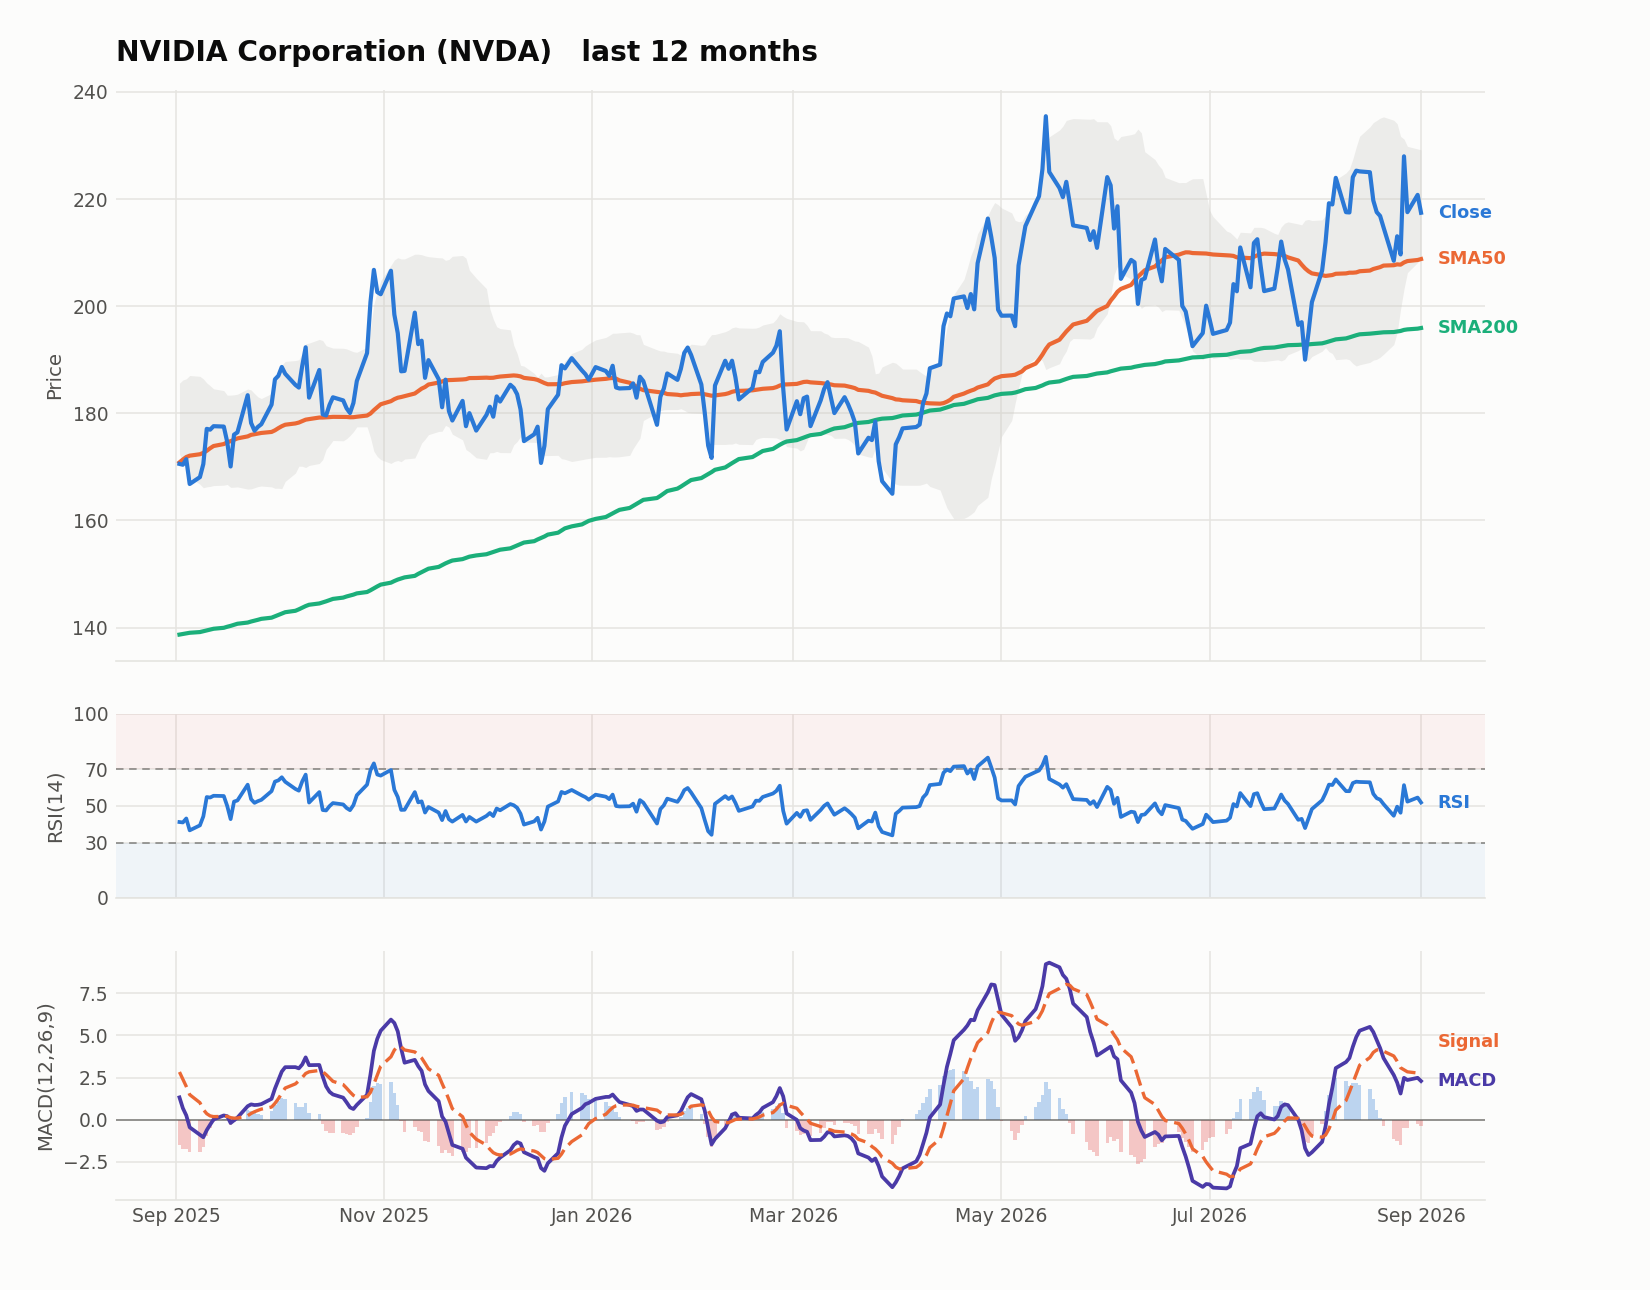

In [13]:
from task1_financial.src import report
from IPython.display import Image, Markdown, display

result = {
    "ticker": TICKER,
    "headline_sentiment": [r.model_dump() for r in outcome.results],
    "sentiment_failures": outcome.failures,
    "classification_success_rate": round(outcome.success_rate, 4),
    "aggregate_sentiment": agg.model_dump(),
    "signal": signal.model_dump(),
    "signal_error": None,
}

paths = report.write_report(summary, result, headlines, enriched=enriched)
for kind, path in paths.items():
    print(f"{kind:9s} {path.name:22s} {path.stat().st_size:>9,} bytes")

display(Image(filename=str(paths["chart"])))

In [14]:
display(Markdown(paths["markdown"].read_text(encoding="utf-8")))

# NVIDIA Corporation (NVDA)

Equity research brief, data as of 2026-09-01. Generated 02 September 2026 at 01:39.

## Company snapshot

| Metric | Value |
| --- | --- |
| Current price | 217.44 USD |
| 52-week range | 164.98 to 235.47 |
| Position in range | 74% of the 52-week range |
| P/E ratio | 27.45 |
| Market cap | 5.25T |
| Year to date return | 15.28% |
| Sector | Technology |
| Bars analysed | 501 since 2024-09-03 |

## Technical outlook

| Indicator | Value |
| --- | --- |
| SMA 50 | 208.80 |
| SMA 200 | 195.92 |
| RSI 14 | 51.87 |
| MACD line | 2.289 |
| MACD signal | 2.671 |
| MACD histogram | -0.382 |
| Bollinger upper | 229.19 |
| Bollinger mid | 219.03 |
| Bollinger lower | 208.87 |
| Percent B | 0.422 |

**Rule-based momentum reading: Bullish** (score 0.25 on a scale of -1 to 1).

Components: trend cross +1, price vs sma50 +1, macd histogram -1, rsi zone 0.

Flags: golden_cross.

## News sentiment

Aggregate sentiment is **positive** at a confidence-weighted score of 0.333 on a scale of -1 to 1, across 10 classified headlines (4 positive, 2 negative, 4 neutral) with a mean confidence of 0.66.

### Top three headlines

1. **5-Star Analyst Drops Massive Nvidia Stock Price Target**  
   *negative, confidence 0.92*. Analyst lowered target price, indicating a negative outlook for the company.

2. **SpaceX Picks Nvidia Chips for Orbital AI. What It Means for NVDA Stock**  
   *positive, confidence 0.92*. SpaceX's adoption of Nvidia chips signals new revenue and market expansion for the company.

3. **Nvidia: Stock Price To Catch Up To Earnings Growth (NASDAQ:NVDA) - Seeking Alpha**  
   *positive, confidence 0.92*. The headline predicts a future rise in NVDA's share price as it aligns with earnings growth.

## Recommendation

### Hold

The price remains above both the 50-day and 200-day SMAs, confirming a longer-term uptrend, but the MACD line sitting below its signal and a negative histogram signal weakening momentum that could lead to a short-term pullback. RSI is near the midpoint, indicating no overbought pressure, while the price sits in the lower half of the Bollinger band, suggesting room for a modest rebound rather than a breakout. Positive news sentiment supports the trend but is not strong enough to outweigh the mixed technical signals, so a cautious stance is warranted.

**Key drivers**

- SMA50>SMA200 uptrend
- MACD bearish divergence
- Price near lower Bollinger band
- Neutral RSI
- Positive news sentiment

## Risk disclaimer

This document is generated by an automated research pipeline for technical demonstration purposes only. It is not investment advice, not a recommendation to buy or sell any security, and not a solicitation of any kind. The signal is produced by a language model reasoning over historical price data and public news headlines. It has not been reviewed by a licensed analyst. Past performance does not predict future results, and technical indicators describe what price has already done rather than what it will do. Anyone acting on this material does so entirely at their own risk and should consult a qualified financial adviser.


# Test suite

All tests run offline with no API key and no network access.

In [15]:
from task1_financial.tests import test_news, test_analysis, test_report
for mod in (test_indicators, test_news, test_analysis, test_report):
    print(f"--- {mod.__name__.split('.')[-1]} ---")
    mod.main()
    print()

--- test_indicators ---
  PASS  test_rsi_matches_wilder                (19 assertions)
  PASS  test_rsi_bounds_and_extremes           (3 assertions)
  PASS  test_sma                               (3 assertions)


WARNING task1_financial.src.analysis: classification failed for 'Nvidia faces new export restrictions': confidence must be <= 1


WARNING task1_financial.src.analysis: 1 of 3 headlines failed classification


WARNING task1_financial.src.analysis: classification failed for 'Nvidia beats on Q2 earnings': all providers failed


WARNING task1_financial.src.analysis: 1 of 3 headlines failed classification


...

WARNING task1_financial.src.analysis: classification failed for 'Nvidia announces routine board change': provider down


WARNING task1_financial.src.analysis: 3 of 3 headlines failed classification


  PASS  test_macd_against_manual_ema           (3 assertions)
  PASS  test_bollinger_population_std          (4 assertions)
  PASS  test_handles_gaps_and_short_series     (3 assertions)

6 tests passed, 35 assertions.

--- test_news ---
  PASS  test_aliases_ignore_corporate_suffixes         (4 assertions)
  PASS  test_relevance_filters_off_topic               (3 assertions)
  PASS  test_ranking_is_binary_not_by_mention_count    (2 assertions)
  PASS  test_dedupe_is_case_and_punctuation_insensitive (2 assertions)

4 tests passed, 11 assertions.

--- test_analysis ---
  PASS  test_happy_path_end_to_end                       (6 assertions)
  PASS  test_aggregation_is_confidence_weighted          (6 assertions)
  PASS  test_aggregate_of_empty_is_none                  (1 assertions)
  PASS  test_validation_failure_is_recorded_not_defaulted (5 assertions)
  PASS  test_transport_error_does_not_abort_the_batch    (3 assertions)
  PASS  test_signal_failure_is_caught                    (3 assert

  PASS  test_html_embeds_chart_and_is_self_contained   (7 assertions)


  PASS  test_chart_handles_short_history               (1 assertions)

6 tests passed, 27 assertions.



# Criteria checklist

| Criterion | Marks | Where |
|---|---|---|
| OHLCV data fetch, 2y+, no hardcoded dates | 10 | `src/data.py`, warm-up buffer for SMA200 |
| Indicator accuracy, five from first principles | 25 | `src/indicators.py`, verified against Wilder |
| News retrieval, ten or more | 10 | `src/news.py`, three sources with relevance ranking |
| Summary dictionary | 10 | `src/summary.py` |
| Robustness | 5 | bad tickers handled, nulls dropped, no magic numbers |
| Per-headline JSON | 10 | four required fields, confidence-weighted aggregation |
| Signal reasoning quality | 15 | reasons over confluences, may override the rule signal |
| Structured output validation | 10 | Pydantic with a self-repair pass, failures logged |
| Prompt engineering | 5 | templates as constants, system carries no request data |
| Bonus, rendered brief | 5 | Markdown, styled HTML, embedded chart, disclaimer |